In [1]:
#Installation of the following packages (if necessary)
#!pip install --upgrade pip setuptools wheel
#!pip install flirimageextractor
#!pip install numpy
#!pip install scikit-image

# get python version
#!python --version # Python version 3.11.13

In [2]:
import flirimageextractor
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import os
from skimage.transform import resize

In [3]:
#List file directories with thermal images per measurement date
main_dir = 'D:\\Bewaesserung_Forstkulturen\\Daten\\Gewaechshaus\\Gewaechshaus_Trockenstress2023\\Thermal\\GH_Analyse_Thermal\\'

main_dir_folders = os.listdir(main_dir)
subfolders = [f for f in main_dir_folders if os.path.isdir(os.path.join(main_dir, f)) and "_Thermal_sorted" in f]
print(subfolders)
#filename= 'ThermalCamera2023-08-03_12-04-30+0200_rgb_image.jpg'
#file = os.path.join(path, filename)


['20230627_Thermal_sorted', '20230629_Thermal_sorted', '20230713_Thermal_sorted', '20230704_Thermal_sorted', '20230718_Thermal_sorted', '20230720_Thermal_sorted', '20230725_Thermal_sorted', '20230731_Thermal_sorted', '20230803_Thermal_sorted', '20230808_Thermal_sorted', '20230811_Thermal_sorted', '20230818_Thermal_sorted']


File paths successfully generated:
DIRP: C:\Users\User\anaconda3\envs\Analysis_Thermal_Droughtstress\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\windows/release_x64/libdirp.dll
DIRP Sub: C:\Users\User\anaconda3\envs\Analysis_Thermal_Droughtstress\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\windows/release_x64/libv_dirp.dll
IIRP: C:\Users\User\anaconda3\envs\Analysis_Thermal_Droughtstress\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\windows/release_x64/libv_iirp.dll
ExifTool: C:\Users\User\anaconda3\envs\Analysis_Thermal_Droughtstress\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\exiftool-12.35.exe


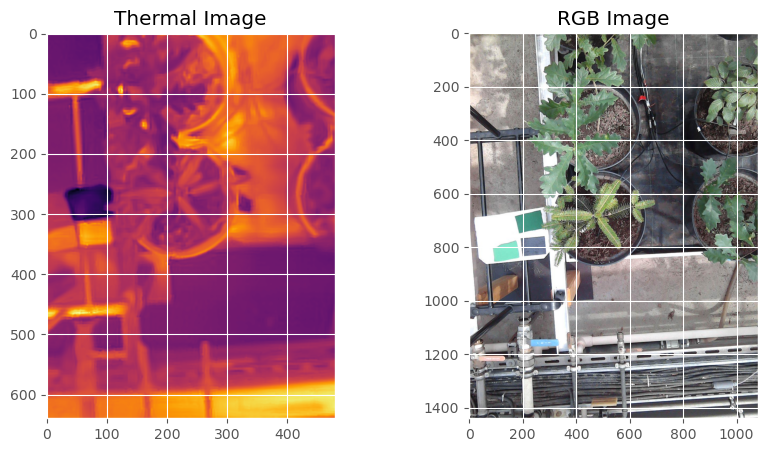

In [4]:
# Load one image using flirimageextractor
filename = 'D:\\Bewaesserung_Forstkulturen\\Daten\\Gewaechshaus\\Gewaechshaus_Trockenstress2023\\Thermal\\GH_Analyse_Thermal\\20230627_Thermal_sorted\\ThermalCamera2023-06-27_15-08-42+0200_T10_W.jpg'

#filename = 'C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\20230627_Thermal_sorted\\ThermalCamera2023-06-27_11-38-16+0200_E13_W.jpg'

flir = flirimageextractor.FlirImageExtractor(exiftool_path="C:\\Users\\User\\AppData\\Local\\Programs\\ExifTool\\exiftool.exe")
flir.process_image(filename, RGB=True)

## Examine thermal and full resolution RGB images
# Most FLIR cameras take a thermal image and a corresponding RGB image. 
# The RGB camera is higher resolution and has a larger field of view. 
thermal = flir.get_thermal_np()
rgb = flir.get_rgb_np()

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(thermal, cmap='inferno')
plt.title('Thermal Image')
plt.subplot(1,2,2)
plt.imshow(rgb)
plt.title('RGB Image')
plt.show(block='TRUE')

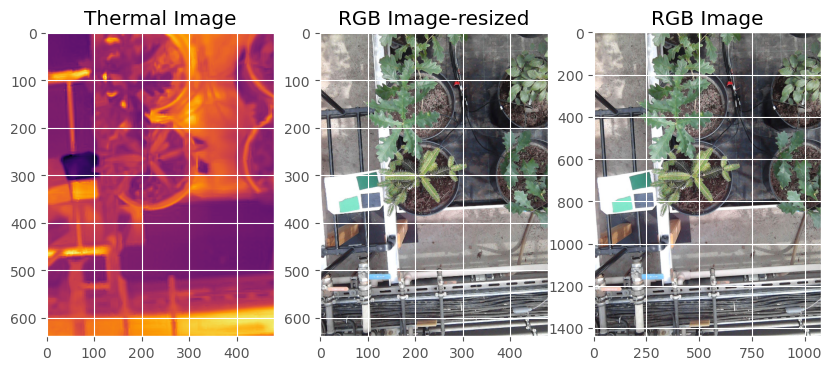

In [6]:
# Resize RGB image to size of thermal image
rgb_resized = cv2.resize(rgb, (thermal.shape[1], thermal.shape[0]))
rgb_resized_for_save = rgb_resized.astype(np.uint8)

# Write out test rgb and resized thermal images
output_path_thermal = 'C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\Test\\ThermalCamera2023-06-27_15-08-42+0200_T10_W_thermal.jpg'
output_path_rgb = 'C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\Test\\ThermalCamera2023-06-27_15-08-42+0200_T10_W_rgb_resized.jpg'
#output_path_thermal = 'C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\Test\\ThermalCamera2023-06-27_11-38-16+0200_E13_W_thermal.jpg'
#output_path_rgb = 'C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\Test\\ThermalCamera2023-06-27_11-38-16+0200_E13_W_rgb_resized.jpg'

cv2.imwrite(output_path_thermal, thermal)
cv2.imwrite(output_path_rgb, rgb_resized_for_save)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(thermal, cmap='inferno')
plt.title('Thermal Image')
plt.subplot(1,3,2)
plt.subplot(1,3,2)
plt.imshow(rgb_resized)
plt.title('RGB Image-resized')
plt.subplot(1,3,3)
plt.imshow(rgb)
plt.title('RGB Image')
plt.show(block='TRUE')

Text(0.5, 1.0, 'Thermal Image')

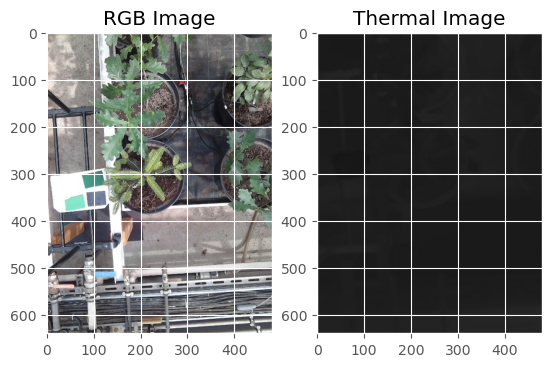

In [7]:
# Image to be registered
image_rgb = cv2.imread('C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\Unused\\Test\\ThermalCamera2023-06-27_15-08-42+0200_T10_W_rgb_resized.jpg')
# Reference image
image_thermal = cv2.imread('C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\Unused\\Test\\ThermalCamera2023-06-27_15-08-42+0200_T10_W_thermal.jpg')

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('RGB Image')

plt.subplot(1, 2, 2)
plt.imshow(image_thermal)
plt.title('Thermal Image')

In [8]:
# get one example temperature values for a selected pixel
value_thermal = thermal[250,350]
print(value_thermal)

30.941332


In [21]:
# create passpoints for referencing the rgb images and thermal images

# Callback-function for mouseclick on rgb image to create passpoints for referencing the rgb images and thermal images
def mouse_callback_rgb(event, x, y, flags, param):
    global rgb_points, thermal_points

    # mouseclick- event
    if event == cv2.EVENT_LBUTTONDOWN:
        # add points on RGB image
        rgb_points.append((x, y))

        # draw points on RGB images
        draw_rgb_image()

# Callback-function for mouseclick on thermal image to create passpoints for georeferencing the rgb images and thermal images
def mouse_callback_thermal(event, x, y, flags, param):
    global rgb_points, thermal_points

    # mouseclick- event
    if event == cv2.EVENT_LBUTTONDOWN:
        # add pints on thermal image (adjusted to image size)
        thermal_points.append((int(x / thermal_scale), int(y / thermal_scale)))

        # draw points on thermal image
        draw_thermal_image()

# draw points on rgb image
def draw_rgb_image():
    global image_rgb, rgb_points

    # copy image to add points on it
    img_rgb_with_points = image_rgb.copy()

    # draw points on image
    for point in rgb_points:
        cv2.circle(img_rgb_with_points, point, 5, (0, 255, 0), -1)

    # show image with reference points
    cv2.imshow('RGB Image with Points', img_rgb_with_points)

# draw points on thermal image
def draw_thermal_image():
    global image_thermal, thermal_points

    # copy image to add points on it
    img_thermal_with_points = image_thermal.copy()

    # draw points on image
    for point in thermal_points:
        cv2.circle(img_thermal_with_points, point, 5, (0, 255, 0), -1)

    # show image with reference points
    cv2.imshow('Thermal Image with Points', img_thermal_with_points)


# Scale thermal image if it is in a different size than the RGB image
thermal_scale = image_thermal.shape[1] / image_rgb.shape[1]

# Initialise empty point list
rgb_points = []
thermal_points = []

# create window for the RGB image
cv2.namedWindow('RGB Image with Points', cv2.WINDOW_NORMAL)
cv2.setMouseCallback('RGB Image with Points', mouse_callback_rgb)

# Change window size 
cv2.resizeWindow('RGB Image with Points', 600, 760)

# create window for the thermal image
cv2.namedWindow('Thermal Image with Points', cv2.WINDOW_NORMAL)
cv2.setMouseCallback('Thermal Image with Points', mouse_callback_thermal)

# Change window size
cv2.resizeWindow('Thermal Image with Points', 600, 760)

# Show RGB image with passpoints
draw_rgb_image()
draw_thermal_image()

# Quit by pressing a key
cv2.waitKey(0)
cv2.destroyAllWindows()

print(rgb_points)
print(thermal_points)

#[(85, 176), (373, 124), (256, 497), (100, 445)]
#[(55, 106), (420, 29), (271, 514), (77, 451)]


[]
[]


False

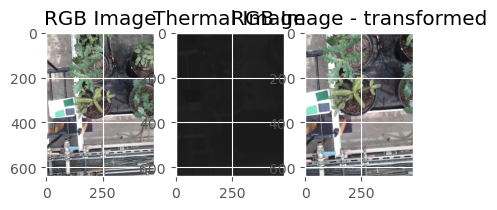

In [23]:
rgb_points = [(85, 176), (373, 124), (256, 497), (100, 445)]
thermal_points = [(55, 106), (420, 29), (271, 514), (77, 451)]

# Convert lists to NumPy arrays
rgb_points_np = np.array(rgb_points)
thermal_points_np = np.array(thermal_points)

rgb_points_np = np.float32(rgb_points_np)
thermal_points_np = np.float32(thermal_points_np)

# Compute the perspective transform M
M = cv2.getPerspectiveTransform(rgb_points_np, thermal_points_np)

# Apply the perspective transformation to the image
rgb_transformed = cv2.warpPerspective(image_rgb, M, (image_thermal.shape[1], image_thermal.shape[0]), flags=cv2.INTER_LINEAR)

# Display the transformed image
plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title('RGB Image')

plt.subplot(1, 4, 2)
plt.imshow(image_thermal, cmap='inferno')
plt.title('Thermal Image')

plt.subplot(1, 4, 3)
plt.imshow(rgb_transformed)
plt.title('RGB Image - transformed')

# Overlay RGB and Thermal Image
merged_image = cv2.addWeighted(rgb_transformed, 0.2, image_thermal, 1, 0) 
cv2.imshow('Merged Image', merged_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

#save images
output_path = 'C:\\Users\\User\\Documents\\Bewaesserung_Forstkulturen\\GH\\Data\\Thermal\\GH_Analyse_Thermal\\Test\\'
cv2.imwrite(os.path.join(output_path , 'ThermalCamera2023-06-27_15-08-42+0200_T10_W_rgb_image_transformed.jpg'), rgb_transformed)
cv2.imwrite(os.path.join(output_path , 'hermalCamera2023-06-27_15-08-42+0200_T10_W_rgb+thermal_transformed.jpg'), merged_image)

In [ ]:
# Loop through every folder and extract one thermal and one rgb imge for every original image, resize the rgb image to the size of the thermal image 
# and write them out as new jpegs.

# Attention: Code cannot handle empy images, needs to be done manually!

# Set the main directory
main_dir = 'D:\\Bewaesserung_Forstkulturen\\Daten\\Gewaechshaus\\Gewaechshaus_Trockenstress2023\\Thermal\\GH_Analyse_Thermal'

main_dir_folders = os.listdir(main_dir)
subfolders = [f for f in main_dir_folders if os.path.isdir(os.path.join(main_dir, f)) and "_Thermal_sorted" in f]

# Set path to Exiftool
flir = flirimageextractor.FlirImageExtractor(exiftool_path="C:\\Users\\User\\AppData\\Local\\Programs\\ExifTool\\exiftool.exe")

# Loop through each subfolder
for subfolder in subfolders:
    # Get the path to the current subfolder
    subfolder_path = os.path.join(main_dir, subfolder)

    # Create a new subfolder named "Processed"
    processed_folder = os.path.join(subfolder_path, 'Processed_new')
    os.makedirs(processed_folder, exist_ok=True)

    # List all files in the subfolder
    files = os.listdir(subfolder_path)

    # Loop through each file in the subfolder
    for file in files:
        # Check if the file is a thermal image
        if "ThermalCamera" in file and file.endswith(".jpg"):
            # Get the full path to the current thermal image
            thermal_image_path = os.path.join(subfolder_path, file)

            # Process the thermal image
            flir.process_image(thermal_image_path, RGB=True)

            # Get thermal and RGB images
            thermal = flir.get_thermal_np()
            rgb = flir.get_rgb_np()

            # Resize RGB to the size of the thermal image
            rgb_resized = cv2.resize(rgb, (thermal.shape[1], thermal.shape[0]))
            rgb_resized_bgr = cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2BGR)
            rgb_resized_for_save = rgb_resized_bgr.astype(np.uint8)

            # Write out the resized RGB and thermal images to the "Processed" subfolder
            output_path_thermal = os.path.join(processed_folder, file.replace(".jpg", "_thermal.jpg"))
            output_path_rgb_resized = os.path.join(processed_folder, file.replace(".jpg", "_rgb_resized.jpg"))

            cv2.imwrite(output_path_thermal, thermal)
            cv2.imwrite(output_path_rgb_resized, rgb_resized_for_save)

print("Resizing complete for all images.")

In [ ]:
# Register RGB images to the thermal images
# Set referencing points for the transformation of the rgb image to the thermal image (received from demo image further above)
rgb_points = [(85, 176), (373, 124), (256, 497), (100, 445)]
thermal_points = [(55, 106), (420, 29), (271, 514), (77, 451)]

# Convert lists to NumPy arrays
rgb_points_np = np.array(rgb_points)
thermal_points_np = np.array(thermal_points)
rgb_points_np = np.float32(rgb_points_np)
thermal_points_np = np.float32(thermal_points_np)

# Compute the perspective transform M
M = cv2.getPerspectiveTransform(rgb_points_np, thermal_points_np)

# Loop through each subfolder
for subfolder in subfolders:
    # Get the path to the current "Processed" subfolder
    processed_folder = os.path.join(main_dir, subfolder, 'Processed_new')

    # Loop through all files in folder
    for file in os.listdir(processed_folder):

        if file.endswith("_thermal.jpg"): 
            thermal_path = os.path.join(processed_folder, file)
            
            # Create the corresponding RGB image file name
            rgb_file = file.replace("_thermal.jpg", "_rgb_resized.jpg")
            rgb_path = os.path.join(processed_folder, rgb_file)
    
            # Check if the corresponding RGB file exists
            if os.path.exists(rgb_path):
                # Load thermal and RGB images
                thermal_image = cv2.imread(thermal_path)
                rgb_image = cv2.imread(rgb_path)
                # print(f"filename image_rgb: {rgb_path}")
                # print(f"filename image_thermal: {thermal_path}")
        
                # Apply the perspective transformation to the RGB image
                rgb_transformed = cv2.warpPerspective(rgb_image, M, (thermal_image.shape[1], thermal_image.shape[0]), flags=cv2.INTER_LINEAR)
              
                # Save the registered RGB image
                output_path_rgb_transformed = os.path.join(processed_folder, f'{file.split(".")[0]}_rgb_transformed.jpg')
                cv2.imwrite(output_path_rgb_transformed, rgb_transformed)
    
# Display a message when processing is complete
print("Registration and transformation complete for all images.")
